# TOPP-HATT

Given some tree, restrict the node and leaf choices of HATT to find the minimum pauli-weight and weighted-pauli-weight tree.

In [1]:
# # Import coefficients
# import pickle
# from ferrmion.encode import TernaryTree
# from pathlib import Path

# def water_integrals():
#     folder = Path.cwd().joinpath(Path("../../../python/tests/"))
#     with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
#         ones = pickle.load(file)

#     with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
#         twos = pickle.load(file)
#     return (ones, twos)
# ones, twos = water_integrals()
# twos *= 0.5

In [2]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode
from openfermion.chem.pubchem import geometry_from_pubchem
from openfermion.chem.molecular_data import MolecularData
from openfermion.chem.molecular_data import spinorb_from_spatial
import openfermionpyscf
import openfermion
geometry=geometry_from_pubchem("H2O")
mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [3]:
"""Code to Geneate Hamiltonian Adaptive Ternary Tree from Majorana Hamiltonian."""

from itertools import permutations
from typing import Iterable

import numpy as np

from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode

def _reduce_hamiltonian(
    majorana_ham: dict[Iterable[int], float],
    parent_index: int,
    selection: tuple[int, int, int],
) -> dict[tuple[int, ...], float]:
    """Simplify the Hamiltonian.

    As we increase the qubit number, we iteratively remove majoranas
    which act trivially on the remaining qubits.
    We replace them with the index of their parent string
    as going forward they are identical to the parent string.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Current Hamiltonian.
        parent_index (int): Qubit index of the parent node.
        selection (tuple[int, int, int]): Indices of the majoranas to be replaced.

    Returns:
        dict[tuple[int,...],float]: Reduced Hamiltonian.
    """
    new_ham = {}
    for term, coeff in majorana_ham.items():
        # new_term = tuple(i if i not in selection else parent_index for i in term)
        new_term = tuple(i for i in term if i not in selection) + tuple(
            parent_index for i in term if i in selection
        )
        if len(set(new_term)) > 1:
            new_ham[new_term] = new_ham.get(new_term, 0) + coeff
    return new_ham


def fast_hatt(
    majorana_ham: dict[Iterable[int], float],
    n_modes: int,
    coeff_weight: bool = False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.
        coeff_weight (bool): Multiply Pauli-weight by coefficient norm.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2 * n_modes + 1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves + i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves + n_modes)}

    total_weight = 0
    for i in range(n_modes + 1):
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        previous = [None, None, None]
        # reverse because best is usually at the end
        # reversed_combinations = [c for c in combinations(unassigned, 2)]
        if i == 0:
            comb_iterator = ([n_leaves - 1, i] for i in range(n_leaves - 1)[::-1])
        else:
            comb_iterator = permutations(unassigned, 2)

        for comb in comb_iterator:
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            z_index, x_index = comb
            # x_index, z_index = comb

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            if comb == previous:
                continue
            previous = comb
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # )
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            elif weight == min_weight:
                #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned

        if i + 1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print("Total Weight: ", total_weight)
    return tree


# POC: Jordan-Wigner

For JW we enforce that we start with the node farthest from the root, then each subsequent node is attached as the Z-parent of the previous.

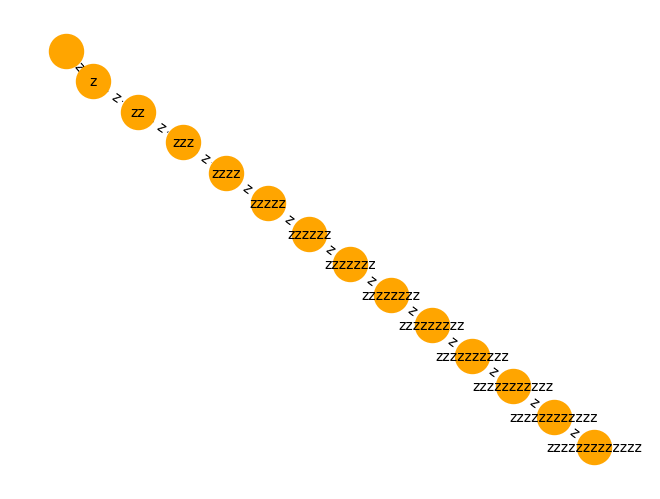

In [4]:
from ferrmion.encode import JordanWigner
from ferrmion.visualise import draw_tt
draw_tt(JordanWigner(14))

In [5]:
def jw_hatt(
    majorana_ham: dict[Iterable[int], float], n_modes: int, coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.
        z_index = unassigned[0]
        for x_index in unassigned[1::2]:
            small_y = None
            small_x = None
            # Now that we are enforcing a topology
            # we actually need to set the combination
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
            #     min_weight = weight
            #     selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

In [6]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 27, 26, 25, 24, 23, 22, 21, 20, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 27, 26, 25, 24, 21, 20, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 27, 26, 25, 24, 21, 20, 13, 12, 9, 8, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 25, 24, 21, 20, 13, 12, 9, 8, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 25, 24, 21, 20, 13, 12, 9, 8, 5, 4, 1, 0]
len(unassigned)=11, unassigned=[37, 25

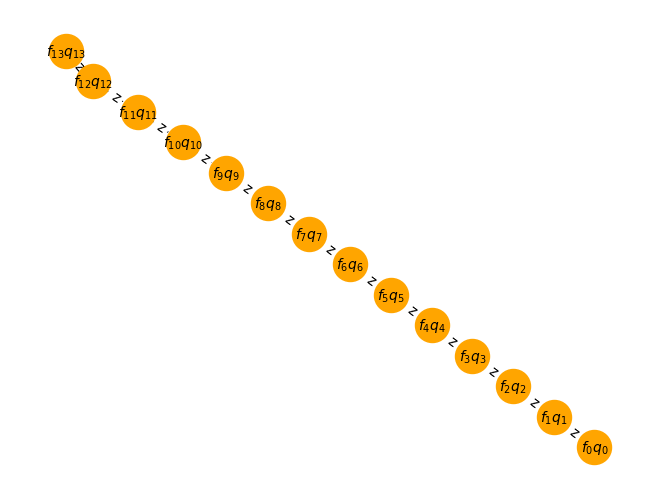

In [7]:
draw_tt(jw_hatt_tree, enumeration_scheme=jw_hatt_tree.default_enumeration_scheme())

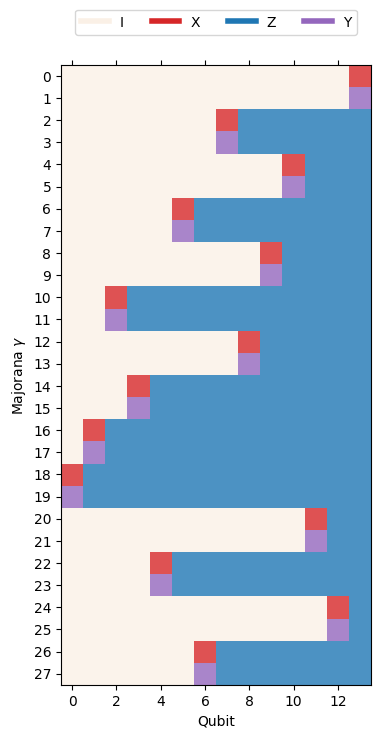

In [8]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree._build_symplectic_matrix()[1])

In [9]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [10]:
from ferrmion.hamiltonians import fill_template, molecular_hamiltonian_template
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

# JW TOPPHATT 

In [11]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)
template = molecular_hamiltonian_template(*jw_hatt_tree._build_symplectic_matrix(), physicist_notation=True)
result = fill_template_find_norms(template, ones, twos, [*range(14)])
sdmeans_topphatt = {}
sdmeans_topphatt["unscaled"] = np.mean(result[0])
sdmeans_topphatt["scaled"] = np.mean(result[1])
sdmeans_topphatt["length"] = result[2]

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 27, 26, 25, 24, 23, 22, 21, 20, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 27, 26, 25, 24, 21, 20, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 27, 26, 25, 24, 21, 20, 13, 12, 9, 8, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 25, 24, 21, 20, 13, 12, 9, 8, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 25, 24, 21, 20, 13, 12, 9, 8, 5, 4, 1, 0]
len(unassigned)=11, unassigned=[37, 25

# JW Naive

In [ ]:
sdmeans_naive = {}
rng = np.random.RandomState(1017)

sym = JordanWigner(ones.shape[0])._build_symplectic_matrix()
template = molecular_hamiltonian_template(*sym, physicist_notation=True)

result = fill_template_find_norms(template, ones, twos, np.array([*range(ones.shape[0])], dtype=np.uint))
sdmeans_naive["unscaled"] = np.mean(result[0])
sdmeans_naive["scaled"] = np.mean(result[1])
sdmeans_naive["length"] = result[2]
sdmeans_naive

# JW Annealed

In [18]:
from ferrmion.core import anneal_enumerations    
import numpy as np
sdmeans_annealed = {}
annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
result = fill_template_find_norms(template, ones, twos, annealed_best[1])
sdmeans_annealed["unscaled"] = np.mean(result[0])
sdmeans_annealed["scaled"] = np.mean(result[1])
sdmeans_annealed["length"] = result[2]
sdmeans_annealed

{'unscaled': np.float64(5.370407149950347),
 'scaled': np.float64(0.10603774135414581),
 'length': 2014}

# JW Random Permutations

In [21]:
limit = 250
sdmeans = {}
sdmeans = {"unscaled":[], "scaled":[], "length":[]}
i=0
while i < limit:
    perm = rng.permutation(ones.shape[0])
    result = fill_template_find_norms(template, ones, twos, perm)
    sdmeans["unscaled"].append(np.mean(result[0])) 
    sdmeans["scaled"].append(np.mean(result[1]))
    sdmeans["length"].append(result[2])
    i+=1
sdmeans.keys()

dict_keys(['unscaled', 'scaled', 'length'])

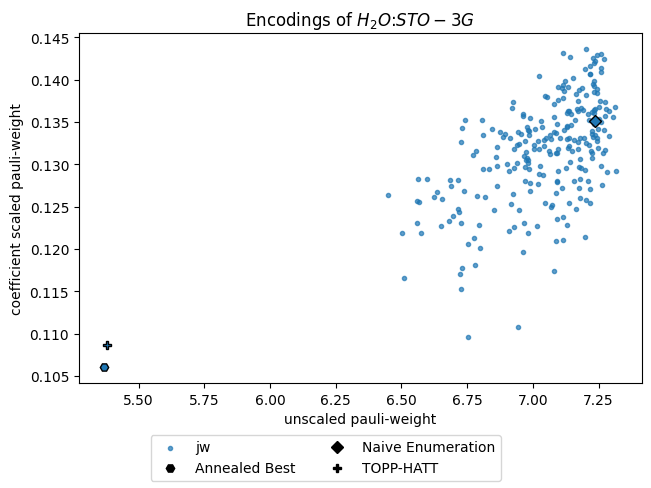

In [22]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
fig, ax = plt.subplots(layout="constrained")

for encoding in ["jw"]:
    color = color_set[encoding]
    # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label=encoding, marker=".", color=color_set[encoding], alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color=color_set[encoding], mec="k")
    ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="H", color=color_set[encoding], mec="k")
    ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color=color_set[encoding], mec="k")


#Imports

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
naive_legend = mlines.Line2D([], [], color='black', label='Naive Enumeration', marker="D", linestyle="")
annealed_legend = mlines.Line2D([], [], color='black', label='Annealed Best', marker="H", linestyle="")
topphatt_legend = mlines.Line2D([], [], color='black', label='TOPP-HATT', marker="P", linestyle="")

# handles is a list, so append manual patch
handles.extend([annealed_legend, naive_legend, topphatt_legend]) 

ax.set_xlabel("unscaled pauli-weight")
ax.set_ylabel("coefficient scaled pauli-weight")
ax.set_title("Encodings of $H_2 O$:$STO-3G$")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)

# Put it all together

In [23]:
geometry=geometry_from_pubchem("SiH4")
mol = MolecularData(geometry=geometry, basis="6-31G", multiplicity=1)
mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [24]:
ones.shape

(42, 42)

In [ ]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.core import anneal_enumerations    
import numpy as np

jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)
template = molecular_hamiltonian_template(*jw_hatt_tree._build_symplectic_matrix(), physicist_notation=True)
result = fill_template_find_norms(template, ones, twos, [*range(14)])
sdmeans_topphatt = {}
sdmeans_topphatt["unscaled"] = np.mean(result[0])
sdmeans_topphatt["scaled"] = np.mean(result[1])
sdmeans_topphatt["length"] = result[2]
print(sdmeans_topphatt)

sdmeans_naive = {}
rng = np.random.RandomState(1017)
sym = JordanWigner(ones.shape[0])._build_symplectic_matrix()
template = molecular_hamiltonian_template(*sym, physicist_notation=True)
result = fill_template_find_norms(template, ones, twos, np.array([*range(ones.shape[0])], dtype=np.uint))
sdmeans_naive["unscaled"] = np.mean(result[0])
sdmeans_naive["scaled"] = np.mean(result[1])
sdmeans_naive["length"] = result[2]
print(sdmeans_naive)

sdmeans_annealed = {}
annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
result = fill_template_find_norms(template, ones, twos, annealed_best[1])
sdmeans_annealed["unscaled"] = np.mean(result[0])
sdmeans_annealed["scaled"] = np.mean(result[1])
sdmeans_annealed["length"] = result[2]
sdmeans_annealed
print(sdmeans_annealed)

limit = 50
sdmeans = {}
sdmeans = {"unscaled":[], "scaled":[], "length":[]}
i=0
while i < limit:
    perm = rng.permutation(ones.shape[0])
    result = fill_template_find_norms(template, ones, twos, perm)
    sdmeans["unscaled"].append(np.mean(result[0])) 
    sdmeans["scaled"].append(np.mean(result[1]))
    sdmeans["length"].append(result[2])
    i+=1
sdmeans.keys()

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
fig, ax = plt.subplots(layout="constrained")

for encoding in ["jw"]:
    color = color_set[encoding]
    # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label=encoding, marker=".", color=color_set[encoding], alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color=color_set[encoding], mec="k")
    ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="H", color=color_set[encoding], mec="k")
    ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color=color_set[encoding], mec="k")


#Imports

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
naive_legend = mlines.Line2D([], [], color='black', label='Naive Enumeration', marker="D", linestyle="")
annealed_legend = mlines.Line2D([], [], color='black', label='Annealed Best', marker="H", linestyle="")
topphatt_legend = mlines.Line2D([], [], color='black', label='TOPP-HATT', marker="P", linestyle="")

# handles is a list, so append manual patch
handles.extend([annealed_legend, naive_legend, topphatt_legend]) 

ax.set_xlabel("unscaled pauli-weight")
ax.set_ylabel("coefficient scaled pauli-weight")
ax.set_title("Encodings of $H_2 O$:$STO-3G$")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)